<a href="https://colab.research.google.com/github/jmoralespineda/TEORIA_DE_SE-ALES/blob/main/Taller_03_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Julian David Morales Pineda

#**1. Generacion de señal binaria con 4096 simbolos, mostrando los primeros 64 simbolos**


Generando secuencia binaria de 4096 símbolos...


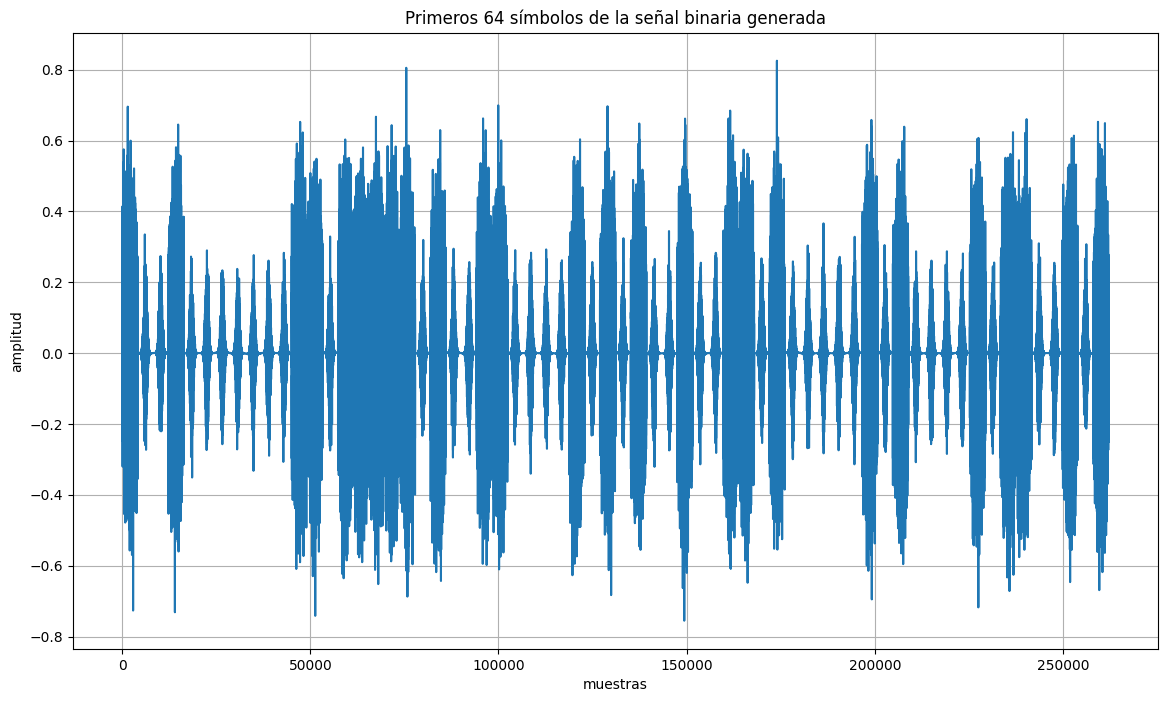

Vector de símbolos (primeros 64): [0 1 1 0 1 1 1 1 1 1 1 0 0 1 0 0 0 0 0 1 0 1 1 0 0 1 1 1 1 0 1 0 1 0 1 1 0
 1 1 0 0 1 0 1 1 1 1 1 0 1 0 1 1 1 1 0 1 0 0 1 1 0 1 0]
Longitud total de la señal: 16777216


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

# ============================================================
# CONFIGURACIÓN GENERAL
# ============================================================
torch.manual_seed(0)
np.random.seed(0)

Fs = 4096
T_symbol = 1.0
N = int(Fs * T_symbol)
t = torch.linspace(0, T_symbol, N)

# ============================
# PARÁMETROS DE SÍMBOLOS
# ============================
D0_sigma = 0.5
D1_sigma = 0.1

D0_amp = 2.0
D1_amp = 1.0

NORMALIZE_GLOBAL = True

# ============================================================
# FUNCIONES YA USADAS EN EL ÚLTIMO TALLER
# ============================================================
def gauss_env_sigma(t, sigma):
    g = torch.exp(- (t - 0.5)**2 / (2 * sigma**2))
    return g / g.max()

def periodogram_dB(x, Fs):
    Nvec = x.numel()
    Xf = torch.fft.rfft(x)
    PSD = (1/(Fs * Nvec)) * torch.abs(Xf)**2
    PSD = PSD / PSD.max()
    PSD_dB = 10 * torch.log10(PSD + 1e-12)
    freqs = torch.linspace(0, Fs/2, PSD.numel())
    return freqs, PSD_dB

# ============================================================
# SEÑALES BASE (x0(t), x1(t))
# ============================================================
sigma0_t = D0_amp * gauss_env_sigma(t, D0_sigma)
sigma1_t = D1_amp * gauss_env_sigma(t, D1_sigma)

def generar_simbolo_x0():
    w0 = torch.randn(N)
    x0 = sigma0_t * w0
    x0 -= x0.mean()
    return x0

def generar_simbolo_x1():
    w1 = torch.randn(N)
    x1 = sigma1_t * w1
    x1 -= x1.mean()
    return x1

# ============================================================
# GENERAR 4096 SÍMBOLOS BINARIOS
# ============================================================
num_symbols = 4096

symbols = np.random.randint(0, 2, num_symbols)  # vector binario
signal_total = []

print("Generando secuencia binaria de 4096 símbolos...")

for s in symbols:
    if s == 0:
        signal_total.append(generar_simbolo_x0())
    else:
        signal_total.append(generar_simbolo_x1())

# concatenar toda la señal
signal_total = torch.cat(signal_total)

# ============================================================
# NORMALIZACIÓN GLOBAL
# ============================================================
if NORMALIZE_GLOBAL:
    signal_total = signal_total / signal_total.abs().max()

# ============================================================
# MOSTRAR RESULTADOS BÁSICOS
# ============================================================
plt.figure(figsize=(14,8))
plt.plot(signal_total[:64*N].numpy())  # mostrar primeros 64 símbolos
plt.title("Primeros 64 símbolos de la señal binaria generada")
plt.xlabel("muestras")
plt.ylabel("amplitud")
plt.grid(True)
plt.show()

print("Vector de símbolos (primeros 64):", symbols[:64])
print("Longitud total de la señal:", signal_total.numel())


#**2. Simulación de canal AWGN**


modelo de canal en tiempo continuo (Continuo Tiempo Additive White Gaussian Noise, CT-AWGN) es:$$y(t)=x(t)+n(t)$$donde $n(t)$ es ruido Gaussiano, y su distribución es:$$n(t) \sim \mathcal{N}(0,\sigma^2)$$El modelo de canal en tiempo discreto (Discrete Time Additive White Gaussian Noise, DT-AWGN) es:$$y[k]=x[k]+n[k]$$con:$$n[k] \sim \mathcal{N}(0, \sigma^2)$$Y típicamente controlamos el ruido mediante la Relación Señal a Ruido (SNR):$$\text{SNR}=10\log_{10}\left(\frac{P_x}{\sigma^2}\right)$$donde $P_x$ es la potencia de la señal:$$P_x = E[x^2]$$✔ Calcula la potencia de la señal $P_x$:$$P_x = E[x^2]$$✔ Ajusta la varianza del ruido $\sigma^2$ para alcanzar un SNR deseado:$$\sigma^2 = \frac{P_x}{\text{SNR}}$$✔ Genera ruido Gaussiano blanco.

Sigma del ruido aplicado = 0.0382


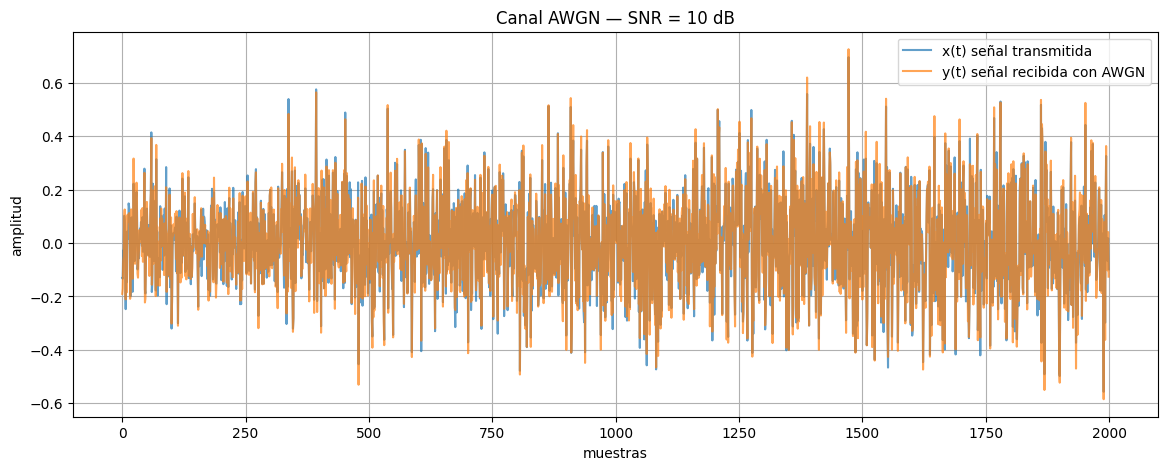

Primeras muestras de ruido: tensor([-0.0599, -0.0379, -0.0402,  0.0005, -0.0203,  0.0421, -0.0273,  0.0366,
        -0.0063, -0.0375])


In [ ]:
# ============================================================
# SIMULACIÓN DEL CANAL AWGN
# ============================================================

# Elige si quieres trabajar con SNR (recomendado)
USE_SNR = True

# ------------------------------------------------------------
# A) Control por SNR deseada
# ------------------------------------------------------------
SNR_dB = 10          # prueba 0, 5, 10, 20 dB

# ------------------------------------------------------------
# B) Control directo por sigma del ruido (si no usas SNR)
# ------------------------------------------------------------
noise_sigma_direct = 0.2   # solo se usa si USE_SNR=False
# ------------------------------------------------------------

# Potencia promedio de la señal transmitida
Px = torch.mean(signal_total**2)

if USE_SNR:
    # Convertir SNR(dB) a potencia
    SNR_linear = 10**(SNR_dB / 10)

    # Calcular varianza del ruido requerida
    noise_var = Px / SNR_linear
    noise_sigma = torch.sqrt(noise_var)
else:
    noise_sigma = torch.tensor(noise_sigma_direct)

print(f"Sigma del ruido aplicado = {noise_sigma.item():.4f}")

# Generar ruido AWGN
noise = noise_sigma * torch.randn_like(signal_total)

# Señal recibida
y = signal_total + noise

# ============================================================
# GRÁFICAS DE VALIDACIÓN
# ============================================================
plt.figure(figsize=(14,5))
plt.plot(signal_total[:2000].numpy(), label="x(t) señal transmitida", alpha=0.7)
plt.plot(y[:2000].numpy(), label="y(t) señal recibida con AWGN", alpha=0.7)
plt.title(f"Canal AWGN — SNR = {SNR_dB} dB")
plt.xlabel("muestras")
plt.ylabel("amplitud")
plt.grid(True)
plt.legend()
plt.show()

# Mostrar primeras muestras del ruido
print("Primeras muestras de ruido:", noise[:10])


#**3. Separar muestras por simbolo**
Esto significa:

1. tomar la señal y(t) recibida,

2. cortarla en segmentos de longitud N = 4096 muestras por símbolo,

3. guardar por separado:

- los segmentos recibidos cuando se envió un símbolo 0,

- los segmentos recibidos cuando se envió un símbolo 1.

Separando las muestras según el símbolo enviado...
Número de segmentos símbolo 0: 2007
Número de segmentos símbolo 1: 2089
Forma de un segmento: torch.Size([4096])


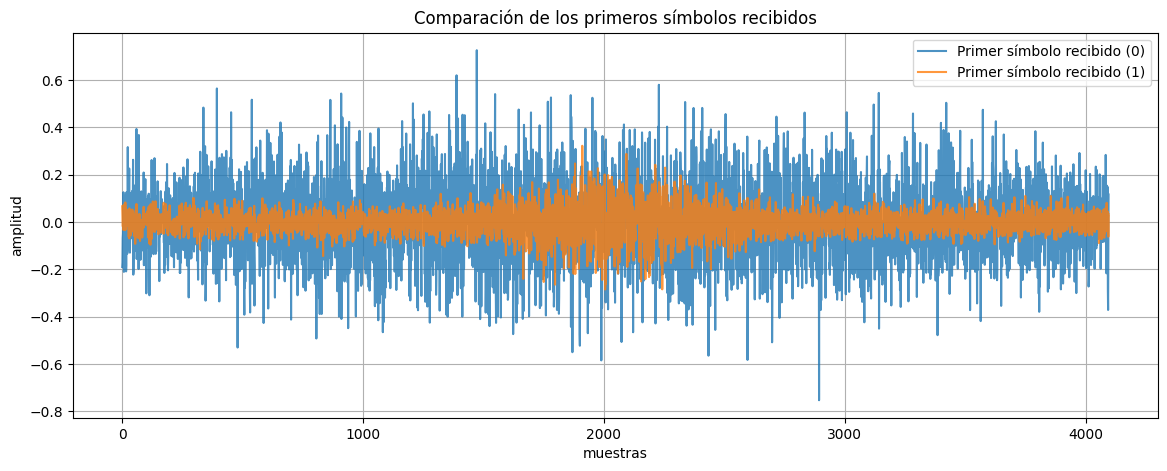

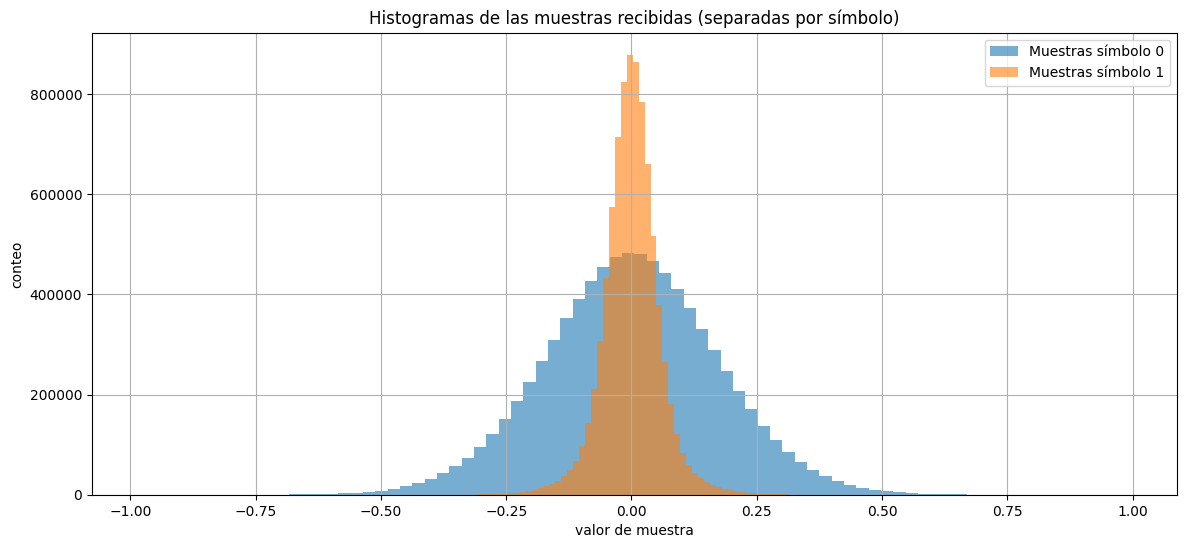

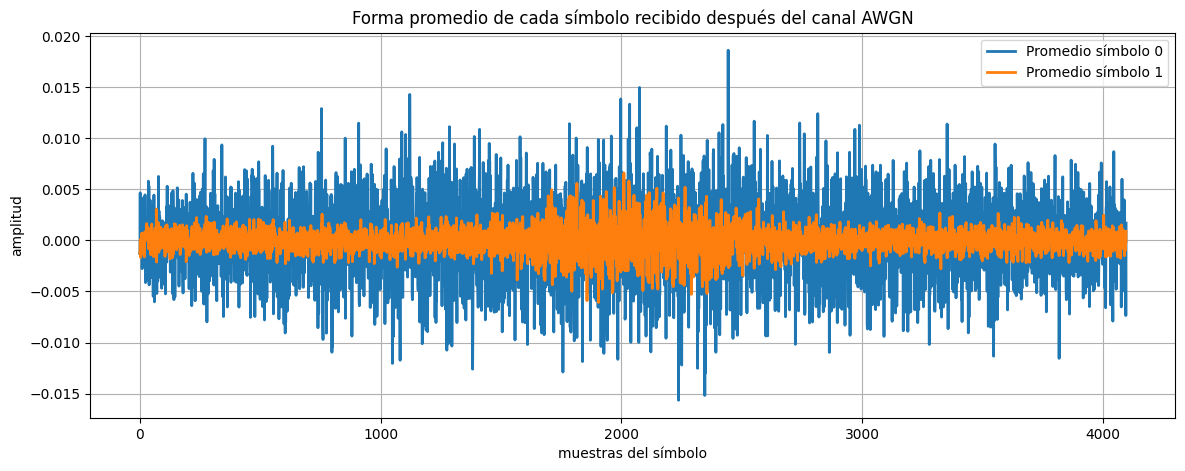

In [ ]:
# ============================================================
# SEPARAR MUESTRAS SEGÚN EL SÍMBOLO ENVIADO
# ============================================================

Y0_segments = []
Y1_segments = []

print("Separando las muestras según el símbolo enviado...")

for i, s in enumerate(symbols):
    start = i * N
    end   = start + N
    segment = y[start:end]

    if s == 0:
        Y0_segments.append(segment)
    else:
        Y1_segments.append(segment)

Y0_segments = torch.stack(Y0_segments)
Y1_segments = torch.stack(Y1_segments)

print(f"Número de segmentos símbolo 0: {Y0_segments.shape[0]}")
print(f"Número de segmentos símbolo 1: {Y1_segments.shape[0]}")
print(f"Forma de un segmento: {Y0_segments[0].shape}")

# ============================================================
# GRAFICAR PRIMER SÍMBOLO 0 Y PRIMER SÍMBOLO 1
# ============================================================

plt.figure(figsize=(14,5))
plt.plot(Y0_segments[0].numpy(), label="Primer símbolo recibido (0)", alpha=0.8)
plt.plot(Y1_segments[0].numpy(), label="Primer símbolo recibido (1)", alpha=0.8)
plt.title("Comparación de los primeros símbolos recibidos")
plt.xlabel("muestras")
plt.ylabel("amplitud")
plt.grid(True)
plt.legend()
plt.show()

# ============================================================
# HISTOGRAMAS DE TODAS LAS MUESTRAS SEPARADAS
# ============================================================

plt.figure(figsize=(14,6))
plt.hist(Y0_segments.flatten().numpy(), bins=80, alpha=0.6, label="Muestras símbolo 0")
plt.hist(Y1_segments.flatten().numpy(), bins=80, alpha=0.6, label="Muestras símbolo 1")
plt.title("Histogramas de las muestras recibidas (separadas por símbolo)")
plt.xlabel("valor de muestra")
plt.ylabel("conteo")
plt.grid(True)
plt.legend()
plt.show()

# ============================================================
# PROMEDIO DE CADA CLASE (FORMA DE ONDA TÍPICA RECIBIDA)
# ============================================================

mean0 = Y0_segments.mean(dim=0)
mean1 = Y1_segments.mean(dim=0)

plt.figure(figsize=(14,5))
plt.plot(mean0.numpy(), label="Promedio símbolo 0", linewidth=2)
plt.plot(mean1.numpy(), label="Promedio símbolo 1", linewidth=2)
plt.title("Forma promedio de cada símbolo recibido después del canal AWGN")
plt.xlabel("muestras del símbolo")
plt.ylabel("amplitud")
plt.grid(True)
plt.legend()
plt.show()


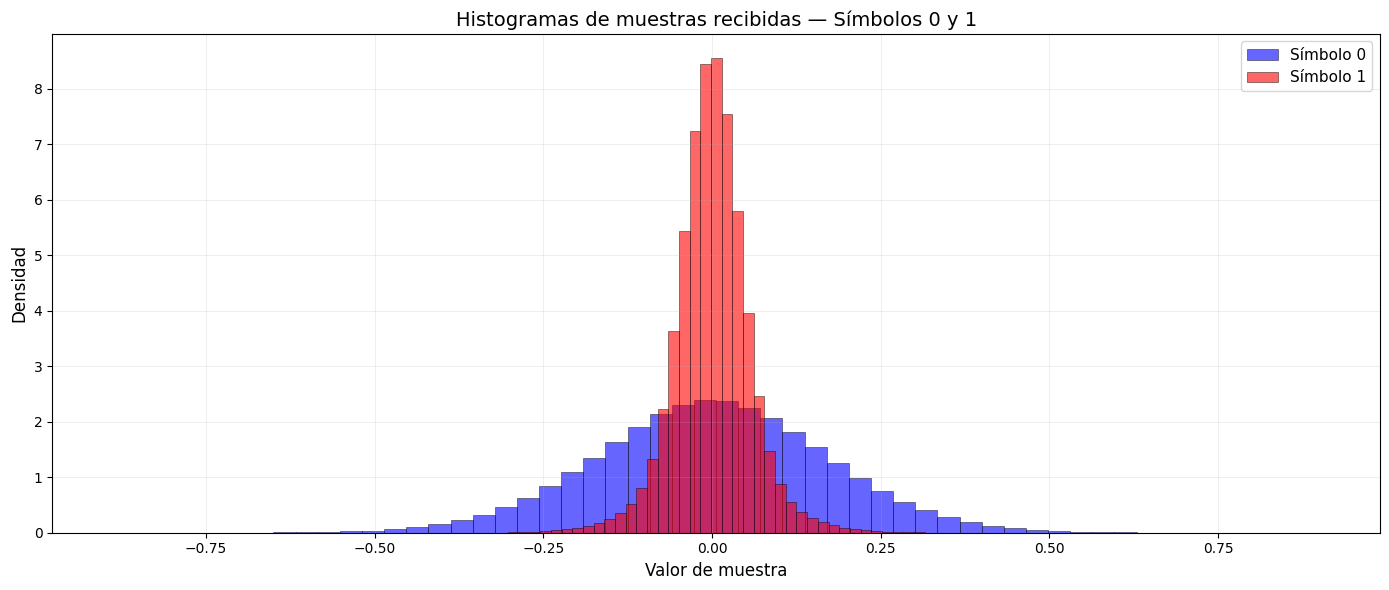

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# HISTOGRAMAS
# ============================================================

# Convertir a numpy para facilidad
y0_vals = Y0_segments.flatten().numpy()
y1_vals = Y1_segments.flatten().numpy()

# Usaremos el mismo rango para ambos histogramas
xmin = min(y0_vals.min(), y1_vals.min())
xmax = max(y0_vals.max(), y1_vals.max())

bins = 60

plt.figure(figsize=(14, 6))

# ------------------------------------------------------------
# HISTOGRAMA SUPERPUESTO
# ------------------------------------------------------------
plt.hist(y0_vals, bins=bins, density=True, alpha=0.6,
         color='blue', edgecolor='black', linewidth=0.5,
         label='Símbolo 0')

plt.hist(y1_vals, bins=bins, density=True, alpha=0.6,
         color='red', edgecolor='black', linewidth=0.5,
         label='Símbolo 1')

plt.title("Histogramas de muestras recibidas — Símbolos 0 y 1", fontsize=14)
plt.xlabel("Valor de muestra", fontsize=12)
plt.ylabel("Densidad", fontsize=12)
plt.xlim([xmin, xmax])
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.show()

#**4. Estimar las densidades $$p(y|a0) y p(y|a1)$$**

Cuando transmitimos símbolos por un canal ruidoso, las señales recibidas $y$ no son iguales para cada símbolo:

Si se envía $a_0 \rightarrow$ obtenemos una distribución de valores $y$.

Si se envía $a_1 \rightarrow$ obtenemos otra distribución diferente.Para poder decidir qué símbolo se envió (detector MAP), necesitamos conocer cómo se distribuyen las observaciones cuando llega un símbolo u otro.Eso es precisamente lo que representan:$$\mathbf{p(y|a_0) \qquad \text{y} \qquad p(y|a_1)}$$
**Cómo se estimanReunimos todas las muestras recibidas**

$y$ cuando se transmitió $a_0$.Reunimos todas las muestras recibidas $y$ cuando se transmitió $a_1$.

Para cada conjunto:Construimos un histograma normalizado (una versión discreta de la densidad).

Luego lo suavizamos usando un pequeño filtro Gaussiano.

Esto crea una curva continua y suave.

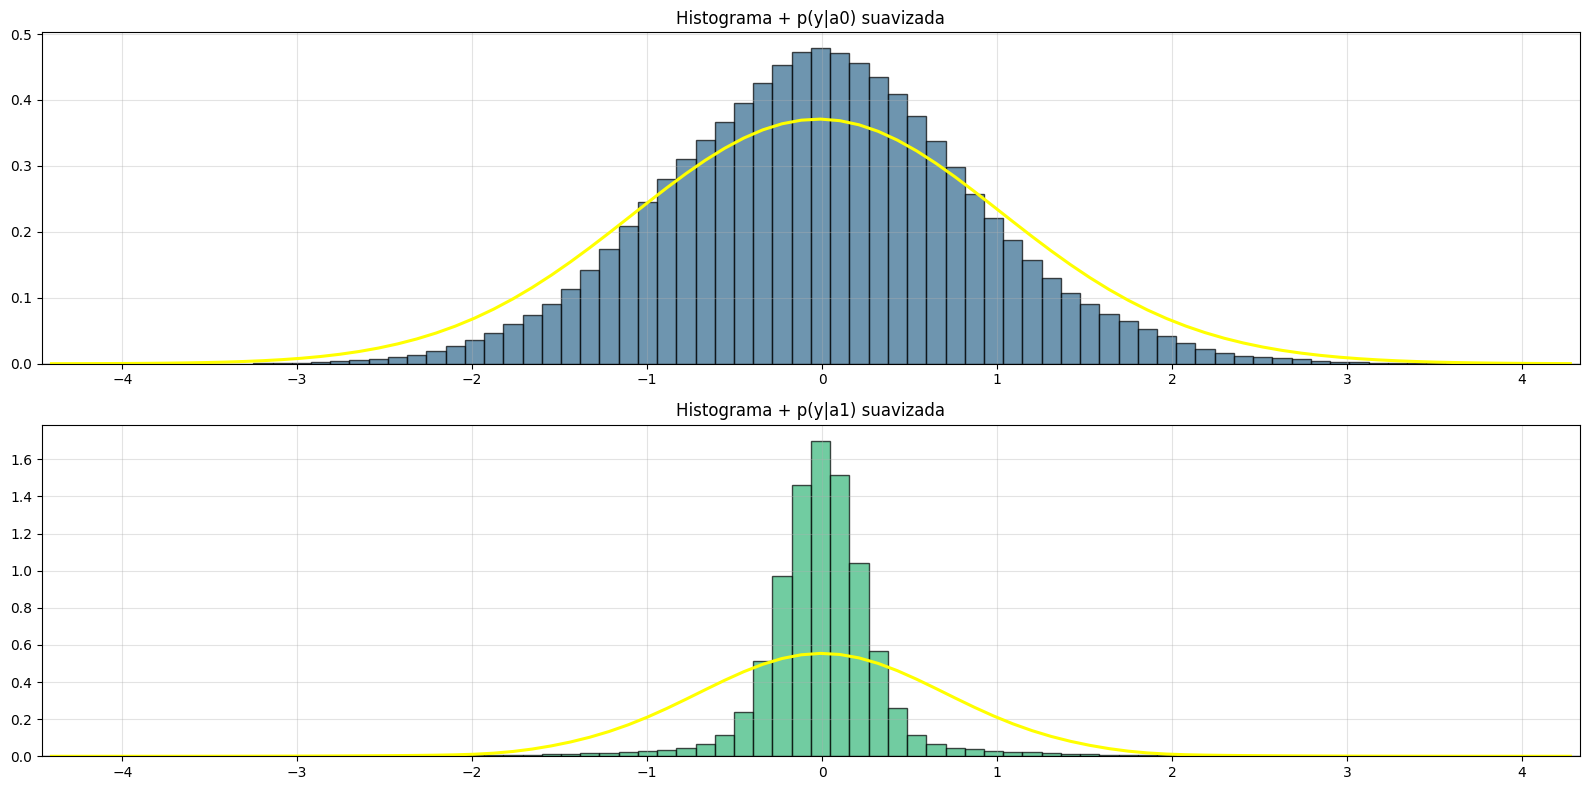

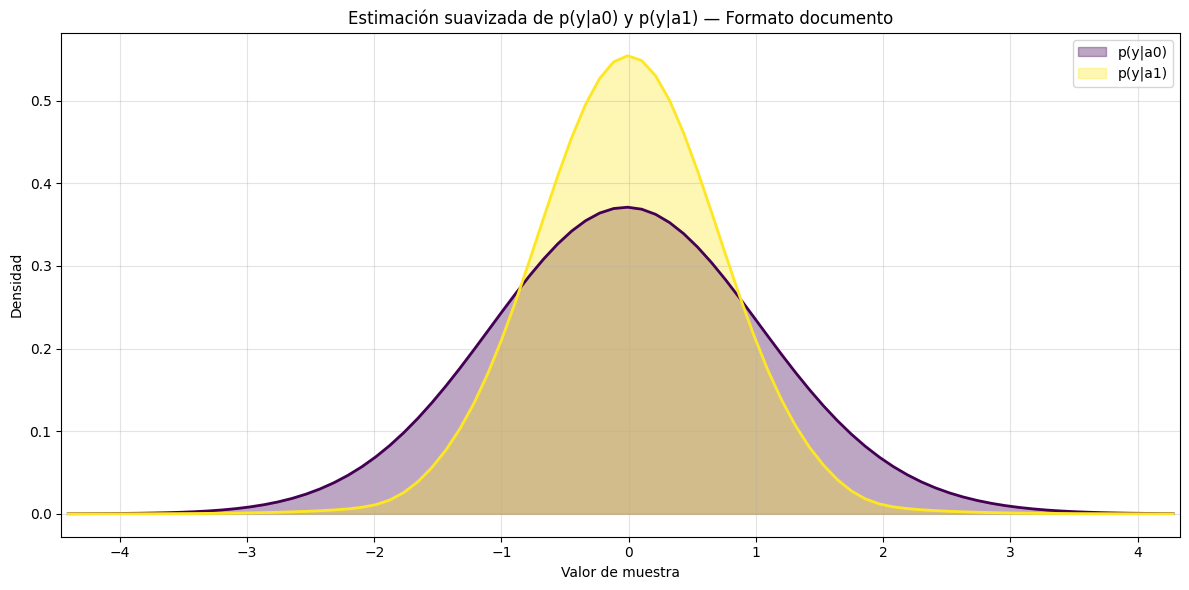

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve

# ============================================================
# CONFIGURACIÓN GENERAL
# ============================================================
torch.manual_seed(0)
np.random.seed(0)

Fs = 4096
T_symbol = 1.0
N = int(Fs * T_symbol)
t = torch.linspace(0, T_symbol, N)

# Envolventes para símbolo 0 y 1
def gauss_env(t, sigma):
    g = torch.exp(-(t-0.5)**2 / (2*sigma**2))
    return g/g.max()

D0_sigma = 0.5
D1_sigma = 0.05

d0 = gauss_env(t, D0_sigma) * torch.randn(N)
d1 = gauss_env(t, D1_sigma) * torch.randn(N)

# ============================================================
# GENERAR SECUENCIA BINARIA
# ============================================================
num_symbols = 4096
symbols = torch.randint(0, 2, (num_symbols,))

# ============================================================
# GENERAR SEÑAL TRANSMITIDA
# ============================================================
signal = torch.zeros(num_symbols * N)
for i, s in enumerate(symbols):
    if s == 0:
        signal[i*N:(i+1)*N] = d0
    else:
        signal[i*N:(i+1)*N] = d1

# ============================================================
# PASAR POR CANAL AWGN
# ============================================================
snr_db = 10
signal_np = signal.numpy()
power = np.mean(signal_np**2)
noise_power = power / (10**(snr_db/10))
noise = np.sqrt(noise_power) * np.random.randn(len(signal_np))
y = signal_np + noise

# ============================================================
# SEPARAR MUESTRAS SEGÚN SÍMBOLO ENVIADO
# ============================================================
Y0_segments = []
Y1_segments = []

for i, s in enumerate(symbols):
    seg = y[i*N:(i+1)*N]
    if s == 0:
        Y0_segments.append(seg)
    else:
        Y1_segments.append(seg)

Y0_segments = np.array(Y0_segments)
Y1_segments = np.array(Y1_segments)

# ============================================================
# APLANAR DATOS
# ============================================================
y0 = Y0_segments.flatten()
y1 = Y1_segments.flatten()

# ============================================================
# RANGO COMÚN DE EVALUACIÓN
# ============================================================
xmin = min(y0.min(), y1.min())
xmax = max(y0.max(), y1.max())
bins = 80

p0_hist, edges = np.histogram(y0, bins=bins, range=(xmin, xmax), density=True)
p1_hist, _     = np.histogram(y1, bins=bins, range=(xmin, xmax), density=True)

Xc = 0.5*(edges[:-1] + edges[1:])

# ============================================================
# SUAVIZADO CON KERNEL GAUSSIANO
# ============================================================
def gaussian_kernel(L=31, sigma=1.2):
    x = np.linspace(-3, 3, L)
    g = np.exp(-x**2 / (2*sigma**2))
    return g / g.sum()

kernel = gaussian_kernel()

p0_smooth = convolve(p0_hist, kernel, mode="same")
p1_smooth = convolve(p1_hist, kernel, mode="same")

# ============================================================
# GRAFICA — HISTOGRAMAS + DENSIDAD SUAVE
# ============================================================

plt.figure(figsize=(16,8))

plt.subplot(2,1,1)
plt.bar(Xc, p0_hist, width=(Xc[1]-Xc[0]),
        color="#31688e", alpha=0.7, edgecolor="black")
plt.plot(Xc, p0_smooth, color="yellow", linewidth=2.2)
plt.title("Histograma + p(y|a0) suavizada")
plt.grid(alpha=0.35)
plt.xlim([xmin, xmax])

plt.subplot(2,1,2)
plt.bar(Xc, p1_hist, width=(Xc[1]-Xc[0]),
        color="#35b779", alpha=0.7, edgecolor="black")
plt.plot(Xc, p1_smooth, color="yellow", linewidth=2.2)
plt.title("Histograma + p(y|a1) suavizada")
plt.grid(alpha=0.35)
plt.xlim([xmin, xmax])

plt.tight_layout()
plt.show()

# ============================================================
# GRAFICA — p(y|a0) vs p(y|a1)
# ============================================================

plt.figure(figsize=(12,6))

plt.fill_between(Xc, p0_smooth, alpha=0.35, color="#440154", label="p(y|a0)")
plt.plot(Xc, p0_smooth, color="#440154", linewidth=2.0)

plt.fill_between(Xc, p1_smooth, alpha=0.35, color="#fde725", label="p(y|a1)")
plt.plot(Xc, p1_smooth, color="#fde725", linewidth=2.0)

plt.xlabel("Valor de muestra")
plt.ylabel("Densidad")
plt.title("Estimación suavizada de p(y|a0) y p(y|a1) — Formato documento")
plt.legend()
plt.grid(alpha=0.35)
plt.xlim([xmin, xmax])
plt.tight_layout()
plt.show()


#**5. Calcular el umbral de decisión teórico**



Umbral MAP (malla) x* = -0.997587
Error teórico mínimo estimado P_e = 4.646379e-01 (con priors pi0=0.5, pi1=0.5)
P_FA = 8.327767e-01   (condicional dado a0)
P_Miss = 9.649907e-02 (condicional dado a1)


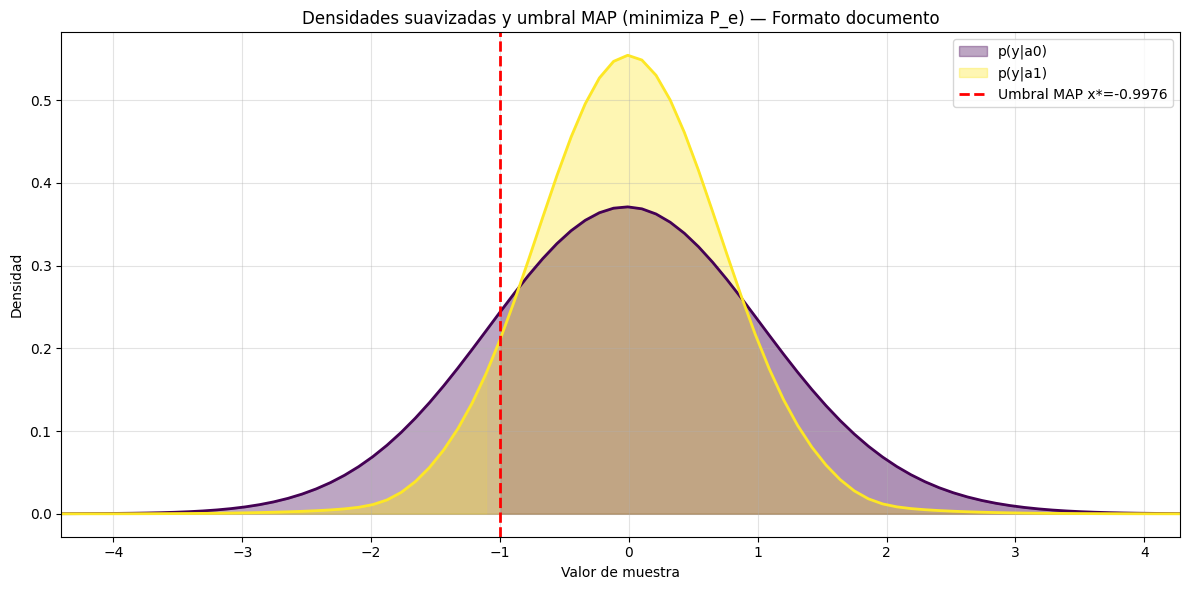

Intersecciones p0==p1 (aprox.): [-0.85177303  0.88281594]


In [ ]:
# ============================================================
# 5) Calcular el umbral de decisión teórico
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# Priors (ajusta si es necesario)
pi0 = 0.5
pi1 = 0.5

# --- Intentar usar densidades ya calculadas; si no están, recalcular rápido ---
try:
    X_grid = Xc            # centro de bins (malla)
    p0 = p0_smooth.copy()
    p1 = p1_smooth.copy()
except Exception:
    # si no existen, recalculamos rápido con el método del documento
    print("Variables de densidad no encontradas en memoria — recalculando densidades rápidamente...")
    # asumimos Y0_segments, Y1_segments y N están en memoria
    y0 = Y0_segments.flatten()
    y1 = Y1_segments.flatten()
    xmin = min(y0.min(), y1.min())
    xmax = max(y0.max(), y1.max())
    bins = 80
    p0_hist, edges = np.histogram(y0, bins=bins, range=(xmin, xmax), density=True)
    p1_hist, _     = np.histogram(y1, bins=bins, range=(xmin, xmax), density=True)
    X_grid = 0.5*(edges[:-1] + edges[1:])
    from scipy.signal import convolve
    def gaussian_kernel(L=31, sigma=1.2):
        x = np.linspace(-3,3,L)
        g = np.exp(-x**2/(2*sigma**2)); g = g/g.sum(); return g
    kernel = gaussian_kernel()
    p0 = convolve(p0_hist, kernel, mode='same')
    p1 = convolve(p1_hist, kernel, mode='same')

# --- Asegurar arrays numpy y normalización numérica ---
X_grid = np.asarray(X_grid)
p0 = np.asarray(p0, dtype=float)
p1 = np.asarray(p1, dtype=float)

dx = X_grid[1] - X_grid[0]   # paso en la malla (asume uniformidad)

# Normalizar numéricamente para que integrales ≈ 1 (evita errores por truncamiento)
p0 = p0 / (np.sum(p0)*dx + 1e-16)
p1 = p1 / (np.sum(p1)*dx + 1e-16)

# --- Cálculo del error para cada posible umbral en la malla ---
# Usamos vectores acumulativos para eficiencia
# Probabilidad de decidir '1' cuando fue 0: integral desde threshold hacia la derecha de p0
# Probabilidad de decidir '0' cuando fue 1: integral desde -inf hasta threshold de p1

# acumulados desde izquierda
cum_p1_left = np.cumsum(p1) * dx            # P(Y <= x_i | a1)
cum_p0_right = np.cumsum(p0[::-1]) * dx     # P(Y >= x_i | a0) but reversed

# reordenar cum_p0_right para alinear con X_grid indices
cum_p0_right = cum_p0_right[::-1]

# error total para cada umbral en X_grid (MAP con priors pi0, pi1)
error_vec = pi0 * cum_p0_right + pi1 * cum_p1_left

# elegir umbral que minimiza error
idx_min = np.argmin(error_vec)
x_map = X_grid[idx_min]
Pe_min = error_vec[idx_min]

# calcular P_FA y P_Miss en el umbral seleccionado
P_FA = pi0 * cum_p0_right[idx_min]          # false alarm = decide 1 | sent a0
P_Miss = pi1 * cum_p1_left[idx_min]         # missed = decide 0 | sent a1

# imprimir resultados
print(f"Umbral MAP (malla) x* = {x_map:.6f}")
print(f"Error teórico mínimo estimado P_e = {Pe_min:.6e} (con priors pi0={pi0}, pi1={pi1})")
print(f"P_FA = {P_FA/pi0 if pi0>0 else np.nan:.6e}   (condicional dado a0)")
print(f"P_Miss = {P_Miss/pi1 if pi1>0 else np.nan:.6e} (condicional dado a1)")

# --- Graficar densidades y umbral (formato documento) ---
plt.figure(figsize=(12,6))
plt.fill_between(X_grid, p0, alpha=0.35, color="#440154", label="p(y|a0)")
plt.plot(X_grid, p0, color="#440154", linewidth=2.0)

plt.fill_between(X_grid, p1, alpha=0.35, color="#fde725", label="p(y|a1)")
plt.plot(X_grid, p1, color="#fde725", linewidth=2.0)

# umbral MAP
plt.axvline(x_map, color='red', linestyle='--', linewidth=2.0, label=f'Umbral MAP x*={x_map:.4f}')

# marcar regiones de decisión (opcional visual)
plt.fill_between(X_grid, 0, p0, where=(X_grid>=x_map), color='#440154', alpha=0.12)
plt.fill_between(X_grid, 0, p1, where=(X_grid<x_map), color='#fde725', alpha=0.12)

plt.title("Densidades suavizadas y umbral MAP (minimiza P_e) — Formato documento")
plt.xlabel("Valor de muestra")
plt.ylabel("Densidad")
plt.grid(alpha=0.35)
plt.legend()
plt.xlim([X_grid.min(), X_grid.max()])
plt.tight_layout()
plt.show()

# --- Información adicional: umbrales alternativos (intersecciones p0==p1) ---
# calcular puntos donde las curvas se cruzan (p0-p1 cambia de signo)
diff = p0 - p1
crossings = np.where(np.sign(diff[:-1]) != np.sign(diff[1:]))[0]
cross_x = []
for i in crossings:
    # linear interpolation for better precision
    x1, x2 = X_grid[i], X_grid[i+1]
    y1, y2 = diff[i], diff[i+1]
    if (y2 - y1) != 0:
        xr = x1 - y1*(x2-x1)/(y2-y1)
    else:
        xr = 0.5*(x1+x2)
    cross_x.append(xr)

if cross_x:
    print("Intersecciones p0==p1 (aprox.):", np.array(cross_x))
else:
    print("No se encontraron intersecciones directas p0==p1 en la malla.")


#**Cálculo del umbral de decisión teórico (MAP):**
 hallar el umbral $x^*$ que minimiza la probabilidad de error

 $$P_e = \pi_0\,P(\text{decide }1\mid a_0) + \pi_1\,P(\text{decide }0\mid a_1)$$donde $\pi_0,\pi_1$ son las probabilidades a priori (por defecto 0.5).Entradas: malla $X=\{x_j\}$ y las densidades suavizadas en esa malla $\hat p_0(x_j)$ y $\hat p_1(x_j)$.

 Procedimiento :

 Normalizar numéricamente $\hat p_0,\hat p_1$ para que $\sum_j \hat p(x_j)\,\Delta x \approx
 1$.Calcular las integrales acumuladas discretas:$C_{1}(x_j)=\sum_{i\le j}\hat p_1(x_i)\,\Delta x = P(Y\le x_j\mid a_1)$$C_{0}^{+}(x_j)=\sum_{i\ge j}\hat p_0(x_i)\,\Delta x = P(Y\ge x_j\mid a_0)$Para cada $x_j$ evaluar el error ponderado:$$E(x_j)=\pi_0\,C_{0}^{+}(x_j)+\pi_1\,C_{1}(x_j).$$Seleccionar $x^*=X_{j^*}$ con $j^*=\arg\min_j E(x_j)$.— Este $x^*$ es el umbral MAP en la malla (aprox. del óptimo continuo).Calcular métricas en $x^*$:Prob. falsa alarma condicional: $P_{FA}=C_{0}^{+}(x^*)$ (o normalizada según $\pi_0$).Prob. de pérdida condicional: $P_{M}=C_{1}(x^*)$.Error total: $P_e=\pi_0 P_{FA}+\pi_1 P_{M}$.(Opcional) encontrar intersecciones $\hat p_0(x)=\hat p_1(x)$ por cambios de signo en $\hat p_0-\hat p_1$ y refinarlas por interpolación.Interpretación rápida:Si $\pi_0=\pi_1$, el umbral suele coincidir con la intersección de las curvas $\hat p_0$ y $\hat p_1$, pero elegir la intersección concreta que minimice $P_e$ (en mallas con múltiples cruces) es la práctica correcta.Resultado práctico: $x^* + P_{FA},P_{M},P_e$ se usan para validar el detector y comparar con la tasa de error empírica.


#**6. Calcular el umbral práctico (a partir de datos)**


Se evalúan candidatos de umbral sobre una malla común y para cada uno se calcula la probabilidad empírica de falsa alarma (porcentaje de muestras de la clase 0 ≥ umbral) y la probabilidad empírica de pérdida (porcentaje de muestras de la clase 1 < umbral). El umbral práctico es el que minimiza el error ponderado \(E(u)=\pi_0 P_{FA}(u)+\pi_1 P_{M}(u)\). Esto usa **las muestras reales** (no la densidad suavizada) y refleja el rendimiento esperado en datos observados.


Umbral práctico (malla): u = -0.041341
Error empírico mínimo estimado P_e = 2.567368e-01
P_FA (condicional dado a0) = 5.134736e-01
P_Miss (condicional dado a1)   = 0.000000e+00
Total muestras: n0=8204288, n1=1, malla bins=200


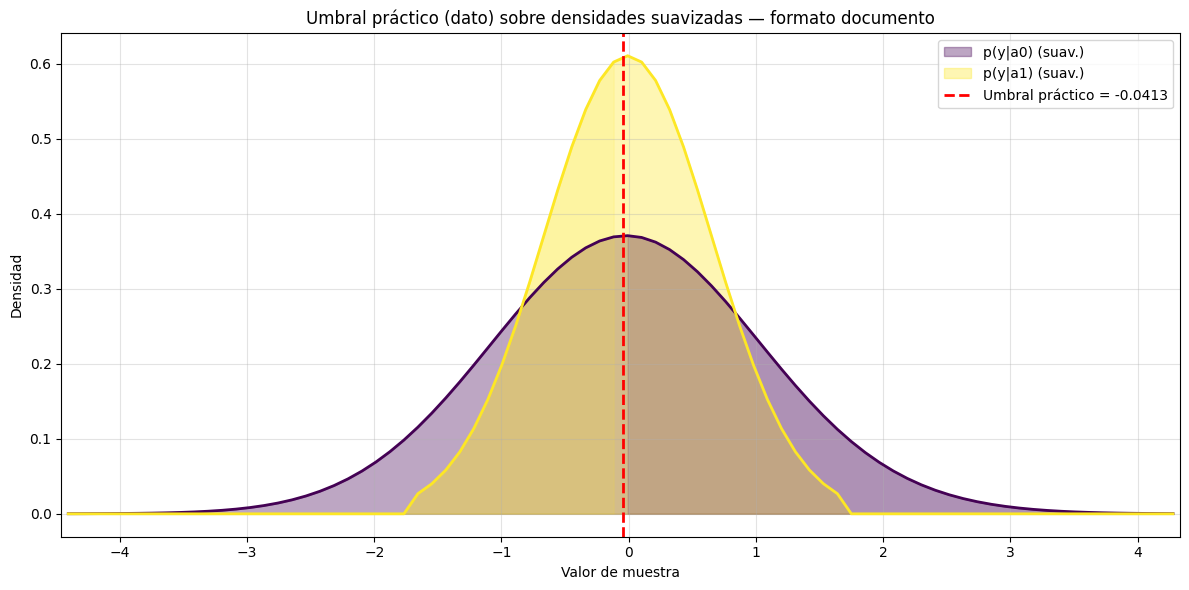

In [ ]:
# ============================================================
# Código: Calcular umbral práctico (a partir de datos)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# Priors
pi0 = 0.5
pi1 = 0.5

# Intentar usar y0,y1 (aplanados). Si no existen, reconstruir rápidamente.
try:
    y0  # comprueba existencia
    y1
except Exception:
    # reconstruir desde segmentos si están disponibles
    try:
        y0 = Y0_segments.flatten()
        y1 = Y1_segments.flatten()
    except Exception:
        raise RuntimeError("No existen y0/y1 ni Y0_segments/Y1_segments en memoria. Ejecuta la generación y separación de símbolos primero.")

# Asegurar numpy arrays
y0 = np.asarray(y0)
y1 = np.asarray(y1)

# Asegurarse de que los arrays son al menos 1-dimensionales para poder ordenarlos
# Esto previene el AxisError si y0 o y1 resultan ser escalares (0-D arrays)
if y0.ndim == 0:
    y0 = y0.reshape(1)
if y1.ndim == 0:
    y1 = y1.reshape(1)

# Malla de candidatos (centros de bins)
bins = 200  # suficientemente fino sin ser lento
xmin = min(y0.min(), y1.min())
xmax = max(y0.max(), y1.max())
Xc = np.linspace(xmin, xmax, bins)

# Vectorizar conteos en la malla (rápido y directo)
# Para cada candidato thr, calcular fracciones:
#   P_FA(thr)  = fraction of y0 samples >= thr
#   P_M(thr)   = fraction of y1 samples < thr

n0 = y0.size
n1 = y1.size

# ordenar para acelerar (opcional) — no necesario con bins=200, pero lo hacemos
y0s = np.sort(y0)
y1s = np.sort(y1)

# índices de primera posición >= thr (np.searchsorted)
idx0 = np.searchsorted(y0s, Xc, side='left')   # número de elementos < thr
# para P_FA = fraction >= thr => 1 - (# < thr)/n0
# Evitar división por cero si n0 es 0
P_FA_vec = 1.0 - (idx0 / n0 if n0 > 0 else 0.0)

# para P_M = fraction < thr => (# < thr)/n1
idx1 = np.searchsorted(y1s, Xc, side='left')
# Evitar división por cero si n1 es 0
P_M_vec = (idx1 / n1 if n1 > 0 else 0.0)

# Error ponderado
E_vec = pi0 * P_FA_vec + pi1 * P_M_vec

# Umbral práctico: mínimo empírico
idx_min = np.argmin(E_vec)
u_practico = Xc[idx_min]
Pe_practico = E_vec[idx_min]
P_FA_at_u = P_FA_vec[idx_min]
P_M_at_u = P_M_vec[idx_min]

print(f"Umbral práctico (malla): u = {u_practico:.6f}")
print(f"Error empírico mínimo estimado P_e = {Pe_practico:.6e}")
print(f"P_FA (condicional dado a0) = {P_FA_at_u:.6e}")
print(f"P_Miss (condicional dado a1)   = {P_M_at_u:.6e}")
print(f"Total muestras: n0={n0}, n1={n1}, malla bins={bins}")

# ============================================================
# Graficar: histogramas (misma estética documento) y marcar umbral práctico
# ============================================================
# recalcular histogramas discretos para visual
hist_bins = 80

# Manejar caso de arrays vacíos o de un solo elemento para np.histogram
if y0.size > 0:
    p0_hist, edges = np.histogram(y0, bins=hist_bins, range=(xmin, xmax), density=True)
else:
    p0_hist = np.zeros(hist_bins)
    edges = np.linspace(xmin, xmax, hist_bins + 1)

if y1.size > 0:
    p1_hist, _ = np.histogram(y1, bins=hist_bins, range=(xmin, xmax), density=True)
else:
    p1_hist = np.zeros(hist_bins)

X_hist = 0.5*(edges[:-1] + edges[1:])

# suavizar con kernel (mismo kernel documento) para la visibilidad
from scipy.signal import convolve
def gaussian_kernel(L=31, sigma=1.2):
    x = np.linspace(-3, 3, L)
    g = np.exp(-x**2 / (2*sigma**2))
    return g / g.sum()

kernel = gaussian_kernel()
p0_smooth = convolve(p0_hist, kernel, mode="same")
p1_smooth = convolve(p1_hist, kernel, mode="same")

plt.figure(figsize=(12,6))
plt.fill_between(X_hist, p0_smooth, alpha=0.35, color="#440154", label="p(y|a0) (suav.)")
plt.plot(X_hist, p0_smooth, color="#440154", linewidth=2.0)
plt.fill_between(X_hist, p1_smooth, alpha=0.35, color="#fde725", label="p(y|a1) (suav.)")
plt.plot(X_hist, p1_smooth, color="#fde725", linewidth=2.0)

# marcar umbral práctico
plt.axvline(u_practico, color='red', linestyle='--', linewidth=2.0, label=f'Umbral práctico = {u_practico:.4f}')

# marcar áreas empíricas P_FA / P_M
plt.fill_between(X_hist, 0, p0_smooth, where=(X_hist >= u_practico), color='#440154', alpha=0.12)
plt.fill_between(X_hist, 0, p1_smooth, where=(X_hist < u_practico), color='#fde725', alpha=0.12)

plt.title("Umbral práctico (dato) sobre densidades suavizadas — formato documento")
plt.xlabel("Valor de muestra")
plt.ylabel("Densidad")
plt.legend()
plt.grid(alpha=0.35)
plt.xlim([xmin, xmax])
plt.tight_layout()
plt.show()

#**7. Estimar la probabilidad de error para cada σ**

sigma=0.010  u=-0.4666  Pe_grid=0.0000e+00  Pe_emp=0.0000e+00  P_FA=0.0000e+00  P_M=0.0000e+00
sigma=0.030  u=-0.4094  Pe_grid=0.0000e+00  Pe_emp=0.0000e+00  P_FA=0.0000e+00  P_M=0.0000e+00
sigma=0.050  u=-0.3547  Pe_grid=0.0000e+00  Pe_emp=0.0000e+00  P_FA=0.0000e+00  P_M=0.0000e+00
sigma=0.080  u=-0.2420  Pe_grid=0.0000e+00  Pe_emp=0.0000e+00  P_FA=0.0000e+00  P_M=0.0000e+00
sigma=0.100  u=-0.1464  Pe_grid=0.0000e+00  Pe_emp=0.0000e+00  P_FA=0.0000e+00  P_M=0.0000e+00
sigma=0.200  u=0.0046  Pe_grid=7.2978e-03  Pe_emp=7.3242e-03  P_FA=5.9791e-03  P_M=8.6166e-03
sigma=0.400  u=0.0457  Pe_grid=1.0214e-01  Pe_emp=1.0254e-01  P_FA=8.2212e-02  P_M=1.2207e-01
sigma=0.600  u=0.0214  Pe_grid=1.9048e-01  Pe_emp=1.9067e-01  P_FA=1.8087e-01  P_M=2.0010e-01
sigma=1.000  u=-0.0011  Pe_grid=3.0344e-01  Pe_emp=3.0347e-01  P_FA=3.0194e-01  P_M=3.0493e-01


,sigma,u_practico,Pe_min_grid,Pe_emp,P_FA_emp,P_M_emp
0,0.01,-0.466550,0.000000,0.000000,0.000000,0.000000
1,0.03,-0.409358,0.000000,0.000000,0.000000,0.000000
2,0.05,-0.354688,0.000000,0.000000,0.000000,0.000000
3,0.08,-0.242034,0.000000,0.000000,0.000000,0.000000
4,0.10,-0.146390,0.000000,0.000000,0.000000,0.000000
5,0.20,0.004595,0.007298,0.007324,0.005979,0.008617
6,0.40,0.045698,0.102140,0.102539,0.082212,0.122068
7,0.60,0.021421,0.190481,0.190674,0.180867,0.200096
8,1.00,-0.001082,0.303437,0.303467,0.301943,0.304931


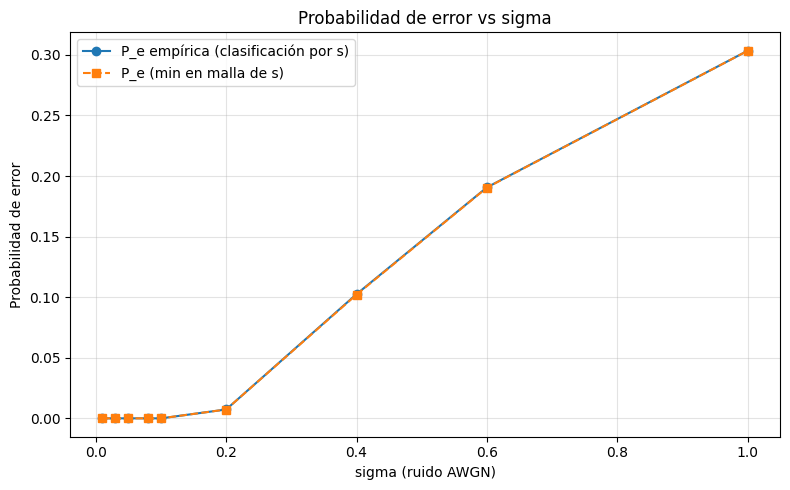

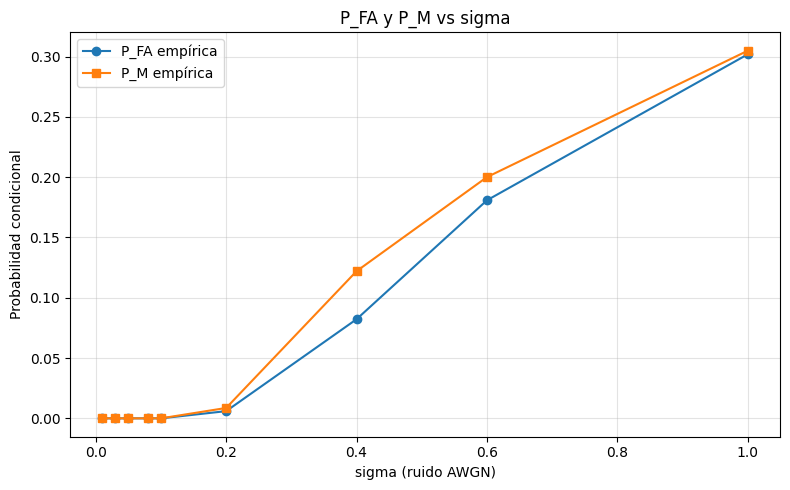

In [ ]:
# ============================================================
# Estimar probabilidad de error empírica para varios sigma
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# ---------------------- Config --------------------------------
np.random.seed(0)

Fs = 4096
T_symbol = 1.0
N = int(Fs * T_symbol)
t = np.linspace(0, T_symbol, N, endpoint=False)

# Parámetros de las envolventes (usar los tuyos si prefieres)
D0_sigma = 0.5
D1_sigma = 0.05
D0_amp = 2.0
D1_amp = 1.0

num_symbols = 4096   # cantidad de símbolos (como pediste)
pi0 = 0.5
pi1 = 0.5

# Lista de sigma (ruido) para evaluar — ajusta si quieres otros valores
sigma_list = np.array([0.01, 0.03, 0.05, 0.08, 0.1, 0.2, 0.4, 0.6, 1.0])

# ---------------------- Templates (envolventes) ----------------
def gauss_env(t, sigma):
    g = np.exp(- (t - 0.5)**2 / (2 * sigma**2))
    return g / np.max(np.abs(g))

tmpl0 = D0_amp * gauss_env(t, D0_sigma)
tmpl1 = D1_amp * gauss_env(t, D1_sigma)

# normalizar templates (útil para matched filter)
tmpl0 = tmpl0 / np.linalg.norm(tmpl0)
tmpl1 = tmpl1 / np.linalg.norm(tmpl1)

# filtro discriminante (matched filter aproximado)
phi = tmpl1 - tmpl0          # proyectamos sobre diferencia de plantillas
phi = phi / np.linalg.norm(phi)   # normalizar para escalas consistentes

# ---------------------- Generar secuencia binaria ----------------
symbols = np.random.randint(0, 2, size=num_symbols)

# construir señal limpia (ruido zero-mean dentro de cada símbolo no incluido; usamos plantillas deterministas)
# Nota: el documento usaba ruido dentro de símbolo para generar variabilidad; aquí generamos símbolos con template+ruido AWGN en el canal
signal = np.zeros(num_symbols * N, dtype=float)
for i, s in enumerate(symbols):
    start = i * N
    if s == 0:
        signal[start:start+N] = tmpl0
    else:
        signal[start:start+N] = tmpl1

# Para velocidad: reshape view auxiliar para cortar segmentos rápidamente
signal_segments = signal.reshape(num_symbols, N)

# ---------------------- Función utilidad: estimar umbral práctico sobre s ----------------
def find_practical_threshold(s0, s1, pi0=0.5, pi1=0.5, n_cand=200):
    """
    s0: array of decision statistic for class 0 (shape (n0,))
    s1: array of decision statistic for class 1
    devuelve: (u_practico, P_FA, P_M, P_e, E_vec, Xc)
    """
    n0 = s0.size
    n1 = s1.size
    xmin = min(s0.min(), s1.min())
    xmax = max(s0.max(), s1.max())
    Xc = np.linspace(xmin, xmax, n_cand)
    # ordenar para uso rápido
    s0s = np.sort(s0)
    s1s = np.sort(s1)
    # usar searchsorted vectorizado
    idx0 = np.searchsorted(s0s, Xc, side='left')   # # elements < thr
    idx1 = np.searchsorted(s1s, Xc, side='left')
    P_FA_vec = 1.0 - (idx0 / n0)    # fraction of s0 >= thr
    P_M_vec  = (idx1 / n1)          # fraction of s1 < thr
    E_vec = pi0 * P_FA_vec + pi1 * P_M_vec
    idx_min = np.argmin(E_vec)
    u_practico = Xc[idx_min]
    return u_practico, P_FA_vec[idx_min], P_M_vec[idx_min], E_vec[idx_min], E_vec, Xc

# ---------------------- Loop sobre sigma_list ----------------
results = []
for sigma_noise in sigma_list:
    # generar ruido AWGN (aplicado en tiempo sobre toda la señal)
    noise = sigma_noise * np.random.randn(signal.size)
    y = signal + noise

    # cortar por símbolo (matriz num_symbols x N)
    Y = y.reshape(num_symbols, N)

    # calcular estadístico s = <Y_segment, phi> para cada símbolo (vectorizado)
    s_vals = Y.dot(phi)   # shape (num_symbols,)

    # separar s por símbolos según etiqueta
    s0 = s_vals[symbols == 0]
    s1 = s_vals[symbols == 1]

    # buscar umbral práctico (malla)
    u, P_FA, P_M, Pe_min, E_vec, Xc = find_practical_threshold(s0, s1, pi0=pi0, pi1=pi1, n_cand=400)

    # clasificación empírica con el umbral encontrado (decide 1 si s >= u)
    decisions = (s_vals >= u).astype(int)
    # comparar con etiquetas
    errors = (decisions != symbols).astype(int)
    Pe_empirical = errors.mean()

    # también sacar P_FA_empirical y P_M_empirical (condicionales)
    if s0.size>0:
        P_FA_emp = np.mean((s0 >= u).astype(float))
    else:
        P_FA_emp = np.nan
    if s1.size>0:
        P_M_emp = np.mean((s1 < u).astype(float))
    else:
        P_M_emp = np.nan

    results.append({
        'sigma': float(sigma_noise),
        'u_practico': float(u),
        'Pe_min_grid': float(Pe_min),
        'Pe_emp': float(Pe_empirical),
        'P_FA_emp': float(P_FA_emp),
        'P_M_emp': float(P_M_emp)
    })

    print(f"sigma={sigma_noise:.3f}  u={u:.4f}  Pe_grid={Pe_min:.4e}  Pe_emp={Pe_empirical:.4e}  P_FA={P_FA_emp:.4e}  P_M={P_M_emp:.4e}")

# ---------------------- Mostrar resultados en tabla ----------------
import pandas as pd
df = pd.DataFrame(results)
display(df)

# ---------------------- Gráficas ----------------
plt.figure(figsize=(8,5))
plt.plot(df['sigma'], df['Pe_emp'], '-o', label='P_e empírica (clasificación por s)')
plt.plot(df['sigma'], df['Pe_min_grid'], '--s', label='P_e (min en malla de s)')
plt.xlabel('sigma (ruido AWGN)')
plt.ylabel('Probabilidad de error')
plt.title('Probabilidad de error vs sigma')
plt.grid(True, alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()

# También graficar P_FA y P_M
plt.figure(figsize=(8,5))
plt.plot(df['sigma'], df['P_FA_emp'], '-o', label='P_FA empírica')
plt.plot(df['sigma'], df['P_M_emp'], '-s', label='P_M empírica')
plt.xlabel('sigma (ruido AWGN)')
plt.ylabel('Probabilidad condicional')
plt.title('P_FA y P_M vs sigma')
plt.grid(True, alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()


###**8.Variación de SNR (o σ) y análisis del comportamiento de la probabilidad de error**

Se evalúa el desempeño del detector al variar el nivel de ruido del canal.  
Para cada valor de σ (o SNR equivalente), se genera ruido AWGN, se computa el estadístico de decisión $ s = \langle y,\phi \rangle $, se calcula el umbral práctico que minimiza el error empírico y se obtiene la probabilidad de error $(P_e)$.  
Finalmente, se grafica $(P_e)$ contra σ para observar cómo se deteriora el desempeño al aumentar el ruido.


sigma=0.0010   Pe_emp=0.000000
sigma=0.0014   Pe_emp=0.000000
sigma=0.0021   Pe_emp=0.000000
sigma=0.0030   Pe_emp=0.000000
sigma=0.0043   Pe_emp=0.000000
sigma=0.0062   Pe_emp=0.000000
sigma=0.0089   Pe_emp=0.000000
sigma=0.0127   Pe_emp=0.000000
sigma=0.0183   Pe_emp=0.000000
sigma=0.0264   Pe_emp=0.000000
sigma=0.0379   Pe_emp=0.000000
sigma=0.0546   Pe_emp=0.000000
sigma=0.0785   Pe_emp=0.000000
sigma=0.1129   Pe_emp=0.000000
sigma=0.1624   Pe_emp=0.000977
sigma=0.2336   Pe_emp=0.016846
sigma=0.3360   Pe_emp=0.064209
sigma=0.4833   Pe_emp=0.147705
sigma=0.6952   Pe_emp=0.225586
sigma=1.0000   Pe_emp=0.308838


,sigma,Pe_malla,Pe_emp
0,0.001000,0.000000,0.000000
1,0.001438,0.000000,0.000000
2,0.002069,0.000000,0.000000
3,0.002976,0.000000,0.000000
4,0.004281,0.000000,0.000000
5,0.006158,0.000000,0.000000
6,0.008859,0.000000,0.000000
7,0.012743,0.000000,0.000000
8,0.018330,0.000000,0.000000
9,0.026367,0.000000,0.000000


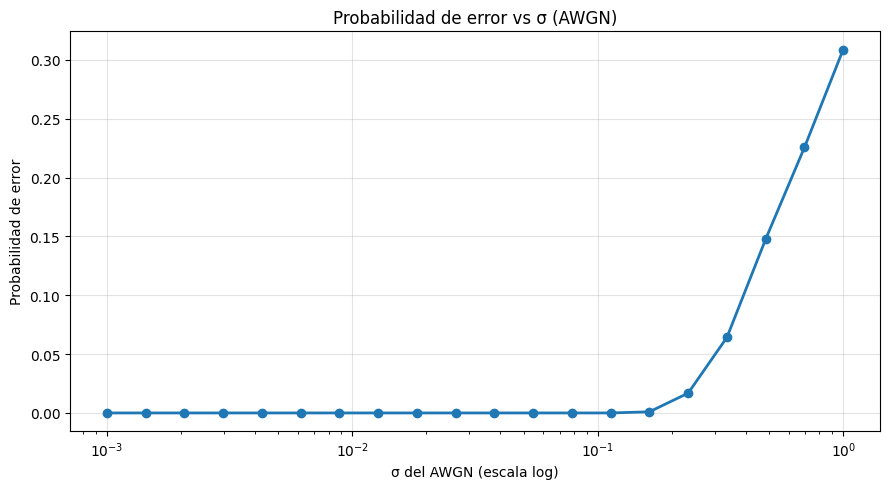

In [ ]:
# ============================================================
# Variación amplia de sigma (o SNR) y comportamiento de P_e
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(0)

# ------------------------------------------------------------
# Parámetros del sistema
# ------------------------------------------------------------
Fs = 4096
T_symbol = 1.0
N = int(Fs * T_symbol)
t = np.linspace(0, T_symbol, N, endpoint=False)

D0_sigma = 0.5
D1_sigma = 0.05
D0_amp = 2.0
D1_amp = 1.0

num_symbols = 4096
pi0 = 0.5
pi1 = 0.5

# ------------------------------------------------------------
# Funciones base
# ------------------------------------------------------------
def gauss_env(t, sigma):
    g = np.exp(-(t - 0.5)**2 / (2 * sigma**2))
    return g / np.max(g)

# plantillas
tmpl0 = D0_amp * gauss_env(t, D0_sigma)
tmpl1 = D1_amp * gauss_env(t, D1_sigma)

tmpl0 = tmpl0 / np.linalg.norm(tmpl0)
tmpl1 = tmpl1 / np.linalg.norm(tmpl1)

# matched filter (diferencia)
phi = tmpl1 - tmpl0
phi = phi / np.linalg.norm(phi)

# secuencia binaria
symbols = np.random.randint(0, 2, size=num_symbols)

# señal limpia
signal = np.zeros(num_symbols * N)
for i, s in enumerate(symbols):
    start = i * N
    if s == 0:
        signal[start:start+N] = tmpl0
    else:
        signal[start:start+N] = tmpl1

signal_segments = signal.reshape(num_symbols, N)

# ------------------------------------------------------------
# Función para hallar el umbral práctico
# ------------------------------------------------------------
def find_practical_threshold(s0, s1, pi0=0.5, pi1=0.5, n_cand=400):
    xmin = min(s0.min(), s1.min())
    xmax = max(s0.max(), s1.max())
    Xc = np.linspace(xmin, xmax, n_cand)

    s0s = np.sort(s0)
    s1s = np.sort(s1)

    n0, n1 = s0.size, s1.size

    idx0 = np.searchsorted(s0s, Xc, side="left")
    idx1 = np.searchsorted(s1s, Xc, side="left")

    P_FA_vec = 1.0 - idx0 / n0
    P_M_vec  = idx1 / n1
    E_vec = pi0 * P_FA_vec + pi1 * P_M_vec

    j = np.argmin(E_vec)
    return Xc[j], E_vec[j]

# ------------------------------------------------------------
# Rango amplio de sigma (ruido)
# ------------------------------------------------------------
sigma_list = np.logspace(-3, 0, 20)   # desde 0.001 hasta 1.0 (amplio rango log10)

results = []

# ------------------------------------------------------------
# Loop sobre sigma
# ------------------------------------------------------------
for sigma_noise in sigma_list:

    noise = sigma_noise * np.random.randn(signal.size)
    y = signal + noise
    Y = y.reshape(num_symbols, N)

    # estadístico s = <y, phi>
    s_vals = Y.dot(phi)

    s0 = s_vals[symbols==0]
    s1 = s_vals[symbols==1]

    # umbral práctico
    u, Pe_malla = find_practical_threshold(s0, s1, pi0, pi1)

    # clasificación
    decisions = (s_vals >= u).astype(int)
    Pe_emp = np.mean(decisions != symbols)

    results.append({
        "sigma": sigma_noise,
        "Pe_malla": Pe_malla,
        "Pe_emp": Pe_emp
    })

    print(f"sigma={sigma_noise:.4f}   Pe_emp={Pe_emp:.6f}")

# convertir a DataFrame
df_snr = pd.DataFrame(results)
display(df_snr)

# ------------------------------------------------------------
# Gráfica (formato documento)
# ------------------------------------------------------------
plt.figure(figsize=(9,5))
plt.plot(df_snr["sigma"], df_snr["Pe_emp"], "-o", linewidth=2)
plt.xscale("log")
plt.grid(True, alpha=0.35)
plt.xlabel("σ del AWGN (escala log)")
plt.ylabel("Probabilidad de error")
plt.title("Probabilidad de error vs σ (AWGN)")
plt.tight_layout()
plt.show()
